# Notebook 02 — Equilibrio de Wardrop (User Equilibrium)

**Objetivo:** Calcular la asignación de flujos en equilibrio de usuario (UE) usando el
principio de Wardrop: *ningún conductor puede reducir su tiempo de viaje cambiando de ruta*.

## Formulación matemática

El equilibrio de Wardrop es equivalente al problema de optimización de Beckmann (1956):

$$\min_{x} \sum_{a} \int_0^{x_a} t_a(u)\, du$$

sujeto a:
- $\sum_r f_r^{od} = d^{od}$ &emsp; (conservación de demanda por par O-D)
- $x_a = \sum_{od,r} f_r^{od} \delta_{ar}$ &emsp; (flujo en arista = suma de rutas que la usan)
- $f_r^{od} \geq 0$

Con función BPR: $t_a(x) = t_a^0 \left(1 + 0.15 \left(\frac{x_a}{c_a}\right)^4\right)$

La integral de Beckmann es convexa → solución única en flujos de arista.

In [21]:
import sys
sys.path.insert(0, '..')

import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice

from src.graph_utils import load_graph, bpr

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'CVXPY version: {cp.__version__}')

CVXPY version: 1.7.5


## 1. Cargar el grafo enriquecido

In [22]:
G = load_graph(RAW_DIR / 'chapinero_drive_enriched.graphml')
for u, v, k, data in G.edges(data=True, keys=True):
    data['t0'] = float(data.get('t0', data.get('length', 60) / 8.33))
    data['capacity'] = float(data.get('capacity', 600))

# Extraer listas de nodos y aristas (orden fijo)
nodes_list = list(G.nodes())
edges_list  = list(G.edges(keys=True))   # (u, v, key)

N = len(nodes_list)
E = len(edges_list)

node_idx = {n: i for i, n in enumerate(nodes_list)}
edge_idx = {e: i for i, e in enumerate(edges_list)}

print(f'Nodos: {N:,}  |  Aristas: {E:,}')

Nodos: 1,821  |  Aristas: 3,670


In [23]:
edges_list = list(G.edges(keys=True))
t0  = np.array([float(G[u][v][k].get('t0',  G[u][v][k]['length'] / 8.33)) for u, v, k in edges_list])
cap = np.array([float(G[u][v][k].get('capacity', 600)) for u, v, k in edges_list])


print(f't0   — min: {t0.min():.1f}s  max: {t0.max():.1f}s  media: {t0.mean():.1f}s')
print(f'cap  — min: {cap.min():.0f}  max: {cap.max():.0f}  media: {cap.mean():.0f} veh/h')

t0   — min: 0.1s  max: 247.6s  media: 11.2s
cap  — min: 600  max: 1800  media: 767 veh/h


## 2. Definir pares O-D de prueba

Para una demostración manejable elegimos un subconjunto de pares origen-destino
representativos de Chapinero (nodos de mayor grado = intersecciones principales).

In [24]:
# Seleccionar los 20 nodos con mayor grado de salida como candidatos O-D
degree_dict = dict(G.out_degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:20]

# Crear 10 pares O-D con demanda sintética (veh/h)
np.random.seed(42)
od_pairs = []
for i in range(0, min(20, len(top_nodes)), 2):
    o, d = top_nodes[i], top_nodes[i+1]
    if o != d and nx.has_path(G, o, d):
        demand = np.random.randint(100, 400)  # veh/h
        od_pairs.append((o, d, demand))

print(f'Pares O-D definidos: {len(od_pairs)}')
for o, d, dem in od_pairs:
    print(f'  {o} → {d}  |  demanda = {dem} veh/h')

Pares O-D definidos: 9
  5233463000 → 264352153  |  demanda = 202 veh/h
  266909155 → 266909156  |  demanda = 370 veh/h
  266909166 → 266909171  |  demanda = 206 veh/h
  266909173 → 268258111  |  demanda = 171 veh/h
  268259045 → 309297259  |  demanda = 288 veh/h
  312423919 → 312643670  |  demanda = 120 veh/h
  339118798 → 339118799  |  demanda = 202 veh/h
  339118810 → 339118811  |  demanda = 221 veh/h
  339119029 → 339119053  |  demanda = 314 veh/h


## 3. Enumerar rutas (k-shortest paths)

Usamos k=3 rutas más cortas por par O-D para mantener el problema tratable.

In [25]:
def k_shortest_paths(G, source, target, k, weight='t0'):
    """Genera hasta k rutas más cortas entre source y target."""
    try:
        gen = nx.shortest_simple_paths(G, source, target, weight=weight)
        return list(islice(gen, k))
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []

K = 3  # rutas por par O-D
routes = {}   # (o, d) -> lista de rutas (cada ruta = lista de nodos)
G_simple = nx.DiGraph(G)

for o, d, dem in od_pairs:
    paths = k_shortest_paths(G_simple, o, d, K, weight='t0')
    if paths:
        routes[(o, d)] = paths

total_routes = sum(len(v) for v in routes.values())
print(f'Rutas enumeradas: {total_routes} ({K} por par O-D)')

Rutas enumeradas: 27 (3 por par O-D)


## 4. Construir la matriz de incidencia ruta-arista

$\delta_{ar} = 1$ si la arista $a$ pertenece a la ruta $r$, 0 en caso contrario.

In [26]:
# Índices de rutas globales
route_list = []  # (od_pair_index, ruta)
od_route_map = {}  # od_pair -> [route_global_indices]

for od, paths in routes.items():
    od_route_map[od] = []
    for path in paths:
        od_route_map[od].append(len(route_list))
        route_list.append((od, path))

R = len(route_list)

# Matriz delta: E x R (dispersa como dict para construir luego)
# Para CVXPY usamos enfoque de flujo en aristas directamente
print(f'Total de rutas: {R}')
print(f'Tamaño de delta: {E} aristas × {R} rutas')

Total de rutas: 27
Tamaño de delta: 3670 aristas × 27 rutas


## 5. Formulación CVXPY — Función de Beckmann

Con BPR, la integral de Beckmann por arista es:

$$\int_0^{x_a} t_a(u)\,du = t_a^0 \left[x_a + \frac{0.15}{5}\frac{x_a^5}{c_a^4}\right]$$

Esta expresión es convexa en $x_a$, lo que permite usar solvers convexos de CVXPY.

In [27]:
def beckmann_bpr(x, t0, cap, alpha=0.15, beta=4):
    """
    Integral de Beckmann con BPR.
    x, t0, cap: vectores de aristas (numpy o cp.Variable)
    Retorna expresión escalar CVXPY.
    """
    # t0 * x  +  t0 * alpha/(beta+1) * x^(beta+1) / cap^beta
    # Para beta=4: t0*x + t0*0.15/5 * x^5 / cap^4
    # cp.power(x, 5) es convexo para x>=0
    term_linear = cp.sum(cp.multiply(t0, x))
    term_power  = cp.sum(
        cp.multiply(t0 * alpha / (beta + 1) / (cap ** beta),
                    cp.power(x, beta + 1))
    )
    return term_linear + term_power

In [28]:
# Variables de flujo por ruta (f_r >= 0)
f = cp.Variable(R, nonneg=True, name='flow_routes')

# Construir matriz delta como numpy array
delta = np.zeros((E, R))
for r_idx, (od, path) in enumerate(route_list):
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Encontrar la arista (puede haber multigrafo)
        if G.has_edge(u, v):
            # Tomar la arista con menor t0
            best_k = min(G[u][v], key=lambda k: G[u][v][k].get('t0', float('inf')))
            e_key = (u, v, best_k)
            if e_key in edge_idx:
                delta[edge_idx[e_key], r_idx] = 1

# Flujos en aristas: x = delta @ f
x = delta @ f   # expresión CVXPY, shape (E,)

print(f'Matriz delta construida: {delta.shape}')
print(f'Densidad: {delta.mean()*100:.2f}%')

Matriz delta construida: (3670, 27)
Densidad: 0.56%


In [29]:
# Restricciones de conservación de demanda
constraints = []
for (o, d, dem) in od_pairs:
    od_key = (o, d)
    if od_key in od_route_map:
        route_idxs = od_route_map[od_key]
        constraints.append(cp.sum(f[route_idxs]) == dem)

# Problema de optimización (Beckmann UE)
objective = cp.Minimize(beckmann_bpr(x, t0, cap))
problem_ue = cp.Problem(objective, constraints)

print(f'Problema UE:')
print(f'  Variables      : {R} (flujos de ruta)')
print(f'  Restricciones  : {len(constraints)}')
print(f'  ¿Es DCP/convexo?: {problem_ue.is_dcp()}')

Problema UE:
  Variables      : 27 (flujos de ruta)
  Restricciones  : 9
  ¿Es DCP/convexo?: True


## 6. Resolver

In [30]:
problem_ue.solve(solver=cp.SCS, verbose=False)

print(f'Estado        : {problem_ue.status}')
print(f'Valor óptimo  : {problem_ue.value:.4f}')

if problem_ue.status not in ['optimal', 'optimal_inaccurate']:
    print('ADVERTENCIA: el solver no encontró solución óptima.')
    print(f'Pares O-D con rutas: {len(od_route_map)}')
    print(f'Pares O-D totales  : {len(od_pairs)}')
    print(f'Restricciones      : {len(constraints)}')
else:
    x_ue = delta @ f.value
    t_ue = np.array([bpr(t0[i], x_ue[i], cap[i]) for i in range(E)])
    print(f'\nFlujos UE — estadísticas:')
    print(f'  Aristas con flujo > 0 : {(x_ue > 1).sum()}')
    print(f'  Flujo máximo          : {x_ue.max():.1f} veh/h')
    print(f'  Flujo medio (activas) : {x_ue[x_ue>1].mean():.1f} veh/h')

Estado        : optimal
Valor óptimo  : 424861.8094

Flujos UE — estadísticas:
  Aristas con flujo > 0 : 225
  Flujo máximo          : 306.7 veh/h
  Flujo medio (activas) : 157.6 veh/h


## 7. Costo total del sistema en UE

In [31]:
# Costo total = suma de (tiempo en arista * flujo en arista)
cost_ue = float(np.sum(t_ue * x_ue))
print(f'Costo total UE (veh·s): {cost_ue:,.0f}')
print(f'Costo total UE (veh·h): {cost_ue/3600:,.1f}')

# Tiempo promedio ponderado por vehículo
total_demand = sum(dem for _, _, dem in od_pairs)
avg_time_ue  = cost_ue / total_demand
print(f'Demanda total          : {total_demand} veh/h')
print(f'Tiempo promedio UE     : {avg_time_ue:.1f} s ({avg_time_ue/60:.2f} min)')

Costo total UE (veh·s): 424,939
Costo total UE (veh·h): 118.0
Demanda total          : 2094 veh/h
Tiempo promedio UE     : 202.9 s (3.38 min)


## 8. Verificar condición de Wardrop

En el equilibrio, todas las rutas usadas tienen el mismo costo mínimo para cada par O-D.

In [32]:
# Construir diccionario de tiempos de arista en UE
t_ue_dict = {edges_list[i]: t_ue[i] for i in range(E)}

print('Verificación de condición de Wardrop por par O-D:')
print(f'{"Par O-D":>30}  {"Rutas":>5}  {"Costo min":>10}  {"Costo max":>10}  {"Gap %":>7}')
print('-' * 70)

for (o, d, dem) in od_pairs:
    od_key = (o, d)
    if od_key not in od_route_map:
        continue
    route_idxs = od_route_map[od_key]
    f_vals = f.value[route_idxs]
    
    route_costs = []
    for r_idx, (_, path) in enumerate(route_list):
        if r_idx in route_idxs:
            cost = sum(
                t_ue_dict.get((path[i], path[i+1], 
                               min(G[path[i]][path[i+1]], 
                                   key=lambda k: G[path[i]][path[i+1]][k].get('t0', float('inf')))), 0)
                for i in range(len(path)-1)
            )
            route_costs.append(cost)
    
    if route_costs:
        c_min, c_max = min(route_costs), max(route_costs)
        gap = (c_max - c_min) / c_min * 100 if c_min > 0 else 0
        print(f'{str(od_key):>30}  {len(route_costs):>5}  {c_min:>10.1f}  {c_max:>10.1f}  {gap:>7.2f}%')

Verificación de condición de Wardrop por par O-D:
                       Par O-D  Rutas   Costo min   Costo max    Gap %
----------------------------------------------------------------------
       (5233463000, 264352153)      3      1142.0      1153.3     0.99%
        (266909155, 266909156)      3         8.2        21.7   165.23%
        (266909166, 266909171)      3        14.7        30.8   110.09%
        (266909173, 268258111)      3       463.6       468.6     1.08%
        (268259045, 309297259)      3       191.7       199.9     4.24%
        (312423919, 312643670)      3       198.6       221.6    11.62%
        (339118798, 339118799)      3         8.8        21.3   141.14%
        (339118810, 339118811)      3         8.8        33.2   275.64%
        (339119029, 339119053)      3        41.8        45.4     8.82%


## 9. Visualización

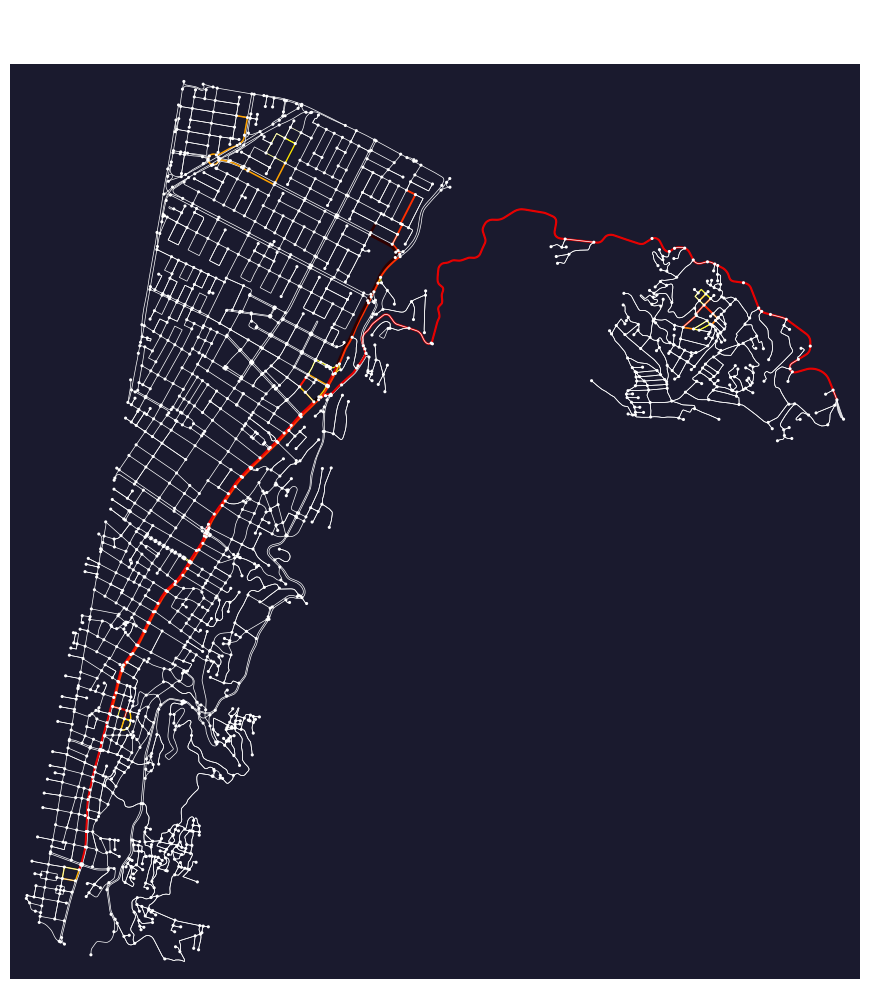

In [33]:
# Asignar flujos UE al grafo para visualización
for i, (u, v, k) in enumerate(edges_list):
    G[u][v][k]['flow_ue']      = float(x_ue[i])
    G[u][v][k]['travel_time_ue'] = float(t_ue[i])

# Colorear por flujo
edge_colors = ox.plot.get_edge_colors_by_attr(G, attr='flow_ue', cmap='hot_r', na_color='#2a2a4a')
edge_widths  = [min(4, 0.5 + G[u][v][k]['flow_ue'] / 200) for u, v, k in edges_list]

fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=5,
    node_color='white',
    bgcolor='#1a1a2e',
    figsize=(12, 10),
    show=False,
    close=False,
)
ax.set_title('Equilibrio de Wardrop — Flujos en aristas (veh/h)\nChapinero, Bogotá',
             color='white', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ue_flows.png', dpi=150, bbox_inches='tight')
plt.show()

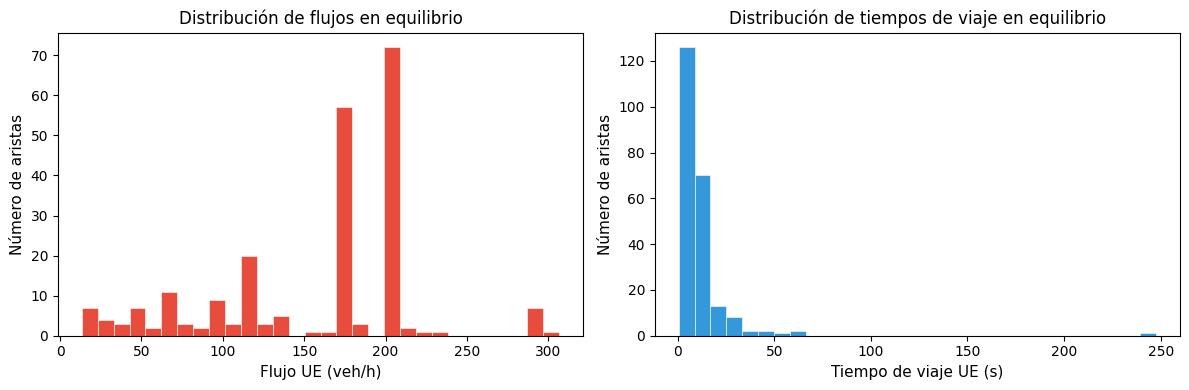

In [34]:
# Histograma de flujos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

active = x_ue[x_ue > 1]
axes[0].hist(active, bins=30, color='#e74c3c', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Flujo UE (veh/h)', fontsize=11)
axes[0].set_ylabel('Número de aristas', fontsize=11)
axes[0].set_title('Distribución de flujos en equilibrio')

axes[1].hist(t_ue[x_ue > 1], bins=30, color='#3498db', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Tiempo de viaje UE (s)', fontsize=11)
axes[1].set_ylabel('Número de aristas', fontsize=11)
axes[1].set_title('Distribución de tiempos de viaje en equilibrio')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ue_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Guardar resultados

In [35]:
import pickle

results_ue = {
    'x_ue':          x_ue,           # flujos en aristas (E,)
    't_ue':          t_ue,           # tiempos de viaje en equilibrio (E,)
    't0':            t0,             # tiempos de viaje libres (E,)
    'cap':           cap,            # capacidades (E,)
    'cost_ue':       cost_ue,        # costo total sistema (veh·s)
    'edges_list':    edges_list,     # lista de aristas (u, v, k)
    'od_pairs':      od_pairs,       # pares O-D con demanda
    'route_list':    route_list,     # rutas enumeradas
    'od_route_map':  od_route_map,   # mapeo O-D → índices de ruta
    'delta':         delta,          # matriz incidencia arista-ruta
}

out_path = PROCESSED_DIR / 'results_ue.pkl'
with open(out_path, 'wb') as fh:
    pickle.dump(results_ue, fh)

print(f'Resultados UE guardados en: {out_path}')
print(f'\nResumen:')
print(f'  Costo total UE : {cost_ue:,.0f} veh·s')
print(f'  Tiempo prom.   : {avg_time_ue:.1f} s')
print(f'  → Listo para Notebook 03 — Óptimo Social')

Resultados UE guardados en: ../data/processed/results_ue.pkl

Resumen:
  Costo total UE : 424,939 veh·s
  Tiempo prom.   : 202.9 s
  → Listo para Notebook 03 — Óptimo Social
